In [1]:
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import obspy


from seismicif.datamod.loading_utils import (
    preproc_flow_annotations,
    find_paths,
    find_date_in_strings,
)
from seismicif.metrics import iou
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from dynamicTreeCut import cutreeHybrid
from scipy.spatial.distance import pdist
from sklearn.ensemble import IsolationForest
from datetime import timedelta
from seismicif.datamod.preproc_utils import preproc_stream


def print_cluster_info(clusters, labels):
    for i in np.unique(clusters):
        cluster_labs = labels[clusters == i]
        cluster_labs_non_none = [x for x in cluster_labs if x is not None]

        if cluster_labs_non_none:
            print(f"Cluster {i}:")
            print(cluster_labs_non_none)
            print(np.sum(clusters == i))

In [2]:
station = "KARAT"
network = "DK"
karat_paths = paths = find_paths("DK", "KARAT", "HHZ.D", start=2022, stop=2023)

In [3]:
catalog = pd.read_csv("../catalogs/DK/KARAT.csv")
catalog = preproc_flow_annotations(catalog)
segments = pd.read_csv(f"../output/{network}/if/segments/{station}.csv", index_col=0)

dtw_path = f"../output/{network}/dtw/distances"

with open(f"{dtw_path}/{station}.pkl", "rb") as f:
    results = pickle.load(f)

X = np.zeros((len(results), len(results[0])))
for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])

In [4]:
labs = []
for i in range(len(segments)):
    I, _, _ = iou(catalog, segments.iloc[[i]].reset_index(drop=True))
    try:
        labs.append(
            catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[0]
        )
    except IndexError:
        labs.append(None)
labs = np.array(labs)

In [5]:
Xa = X.copy()
for i in range(Xa.shape[1]):
    x = np.delete(Xa[:, i], i)
    Xa[i, i] = np.min(x)

lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens).reshape(-1, 1)

Xa = np.hstack(
    [Xa, segments[["scores"]].values, lens, segments[["control_scores"]].values]
)
Xa = np.hstack([Xa, np.isnan(Xa[:, -1]).astype(float).reshape(-1, 1)])
Xa = np.nan_to_num(Xa, nan=0.5)
a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

In [7]:
Z = linkage(Xa, method="ward")
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]
segments["cluster"] = clusters
segments["label"] = labs
segments.to_csv(f"../output/{network}/if/segments/{station}.csv")

..cutHeight not given, setting it to 30.106001162630267  ===>  99% of the (truncated) height range in dendro.
..done.


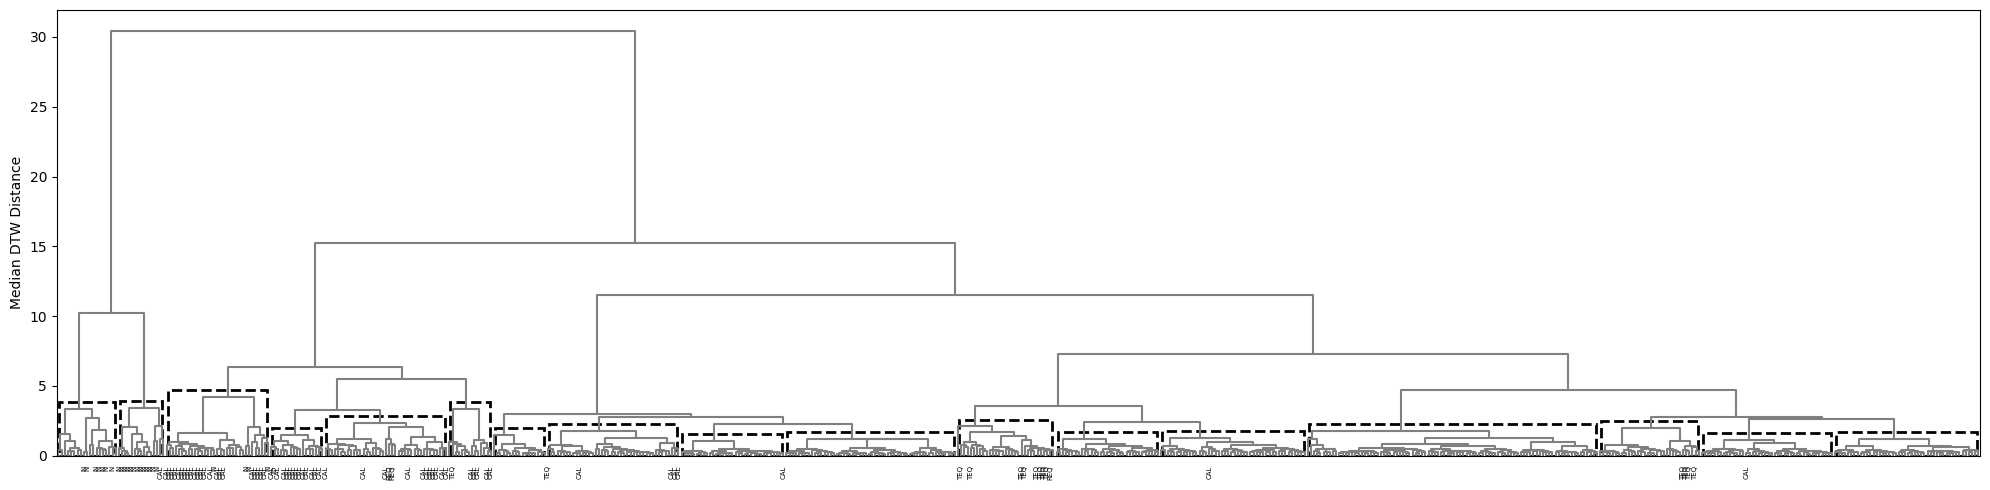

In [8]:
plt.figure(figsize=(20, 5))
# --- dendrogram ---
ddata = dendrogram(Z, labels=labs, link_color_func=lambda k: "grey")

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()

# x positions of leaves (scipy convention)
x_positions = np.arange(len(leaf_order)) * 10 + 5

# --- build tree structure to get correct heights ---
n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

# --- compute height per cluster ---
cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])

# --- draw one box per cluster ---
gap = 8  # spacing so boxes don't touch

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    x0 = x_positions[idx.min()] - 5 + gap
    x1 = x_positions[idx.max()] + 5 - gap
    height = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (x0, 0),
        x1 - x0,
        height,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

plt.ylabel("Median DTW Distance")
plt.tight_layout()
plt.savefig("../plots/karat_dendrogram.pdf", dpi=300)
plt.show()

In [9]:
cl = 10
cluster = segments[clusters == cl].copy().reset_index(drop=True)
cluster

,start,stop,most_anomalous_start,scores,control_scores,cluster,label
0,2022-06-03T10:01:34.625000Z,2022-06-03T10:05:44.625000Z,2022-06-03T10:04:04.625000Z,0.742787,0.366732,10,N
1,2023-08-25T12:39:10.000000Z,2023-08-25T12:47:30.000000Z,2023-08-25T12:41:40.000000Z,0.720424,0.453202,10,CAL
2,2022-08-16T12:32:30.000000Z,2022-08-16T12:41:40.000000Z,2022-08-16T12:35:00.000000Z,0.716862,0.413724,10,N
3,2022-08-15T22:40:54.845000Z,2022-08-15T22:55:54.845000Z,2022-08-15T22:43:24.845000Z,0.702885,0.416311,10,N
4,2022-11-17T12:00:18.390000Z,2022-11-17T12:03:38.390000Z,2022-11-17T12:01:08.390000Z,0.685305,0.504078,10,CAL
5,2023-08-15T03:56:40.000000Z,2023-08-15T04:00:00.000000Z,2023-08-15T03:57:30.000000Z,0.684699,0.382714,10,CAL
6,2023-06-10T11:09:02.320000Z,2023-06-10T11:12:22.320000Z,2023-06-10T11:09:02.320000Z,0.682479,0.414362,10,CAL
7,2023-09-18T13:38:25.410000Z,2023-09-18T13:43:25.410000Z,2023-09-18T13:40:05.410000Z,0.678498,0.443243,10,CAL
8,2022-09-21T22:12:12.395000Z,2022-09-21T22:15:32.395000Z,2022-09-21T22:12:12.395000Z,0.670336,0.460285,10,CAL
9,2023-06-12T09:46:32.320000Z,2023-06-12T09:50:42.320000Z,2023-06-12T09:46:32.320000Z,0.658948,0.512811,10,CAL


In [151]:
seg = cluster.iloc[0]
print(seg)
dt = str(seg["most_anomalous_start"])[:10]
t0 = obspy.UTCDateTime(seg["start"]) - timedelta(minutes=2)
t1 = obspy.UTCDateTime(seg["stop"]) + timedelta(minutes=2)
# t0 = obspy.UTCDateTime(seg["most_anomalous_start"]) #- timedelta(minutes=2)
# t1 = obspy.UTCDateTime(seg["most_anomalous_start"]) + timedelta(minutes=2)

start                   2022-06-03T10:01:34.625000Z
stop                    2022-06-03T10:05:44.625000Z
most_anomalous_start    2022-06-03T10:04:04.625000Z
scores                                     0.742787
control_scores                             0.366732
cluster                                          10
label                                             N
Name: 0, dtype: object


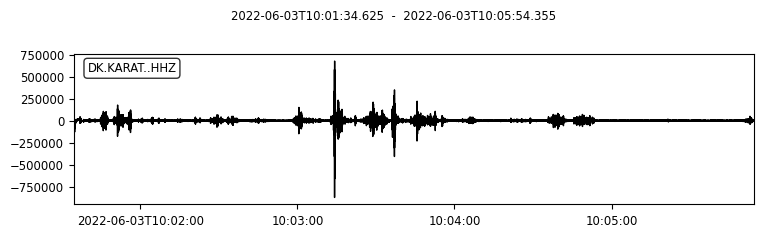

In [152]:
st = obspy.read(find_date_in_strings(paths, dt)[0])
preproc_stream(st)
st.trim(t0, t1)
st.plot()
plt.show()

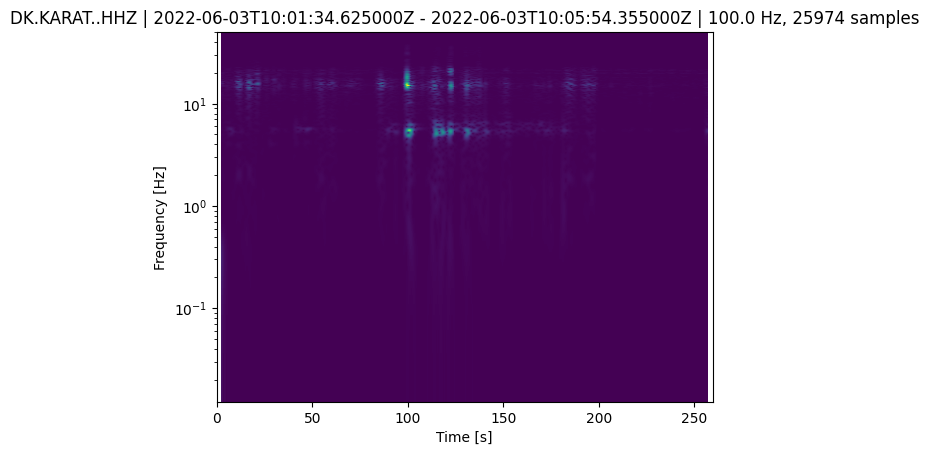

In [153]:
st[0].spectrogram(log=True, wlen=4, show=False)
plt.show()

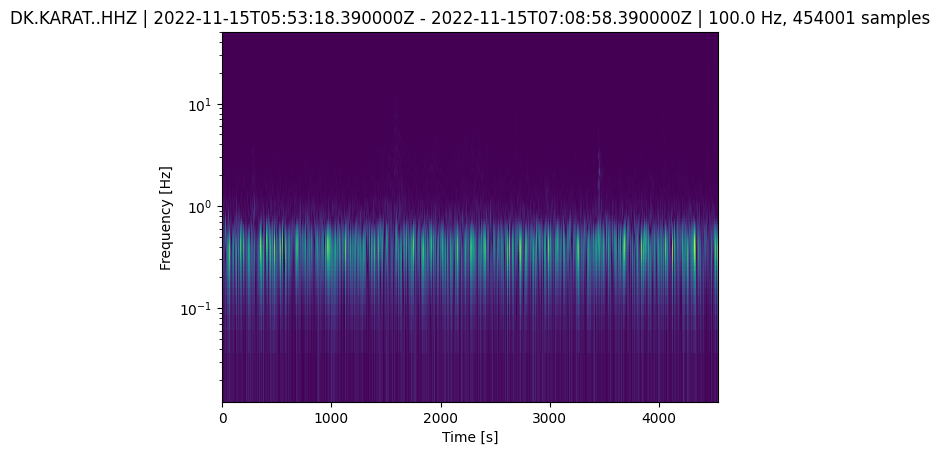

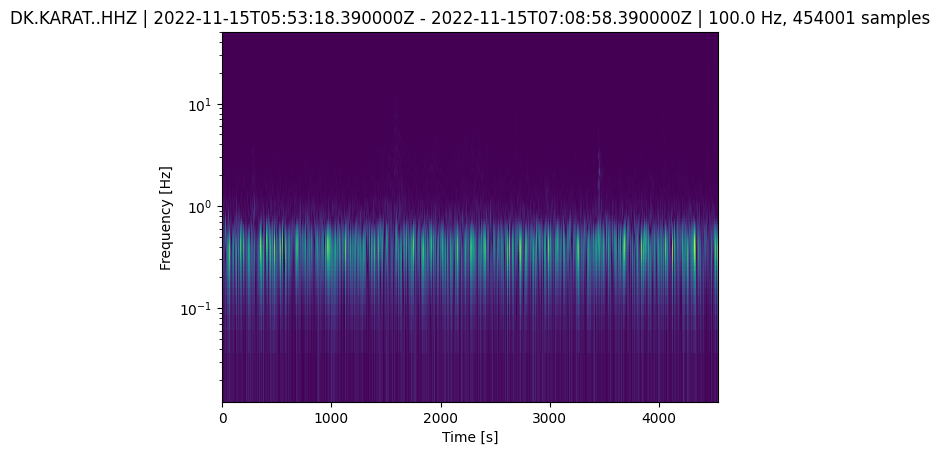

In [59]:
st[0].spectrogram(log=True, wlen=4, show=False)

### NUUG

In [10]:
station = "NUUG"
network = "DK"
nuug_paths = find_paths(network, station, "HHZ.D", start=2017, stop=2017)
segments = pd.read_csv(f"../output/{network}/if/segments/{station}.csv", index_col=0)

In [11]:
dtw_path = f"../output/{network}/dtw/distances"

with open(f"{dtw_path}/{station}.pkl", "rb") as f:
    results = pickle.load(f)

X = np.zeros((len(results), len(results[0])))
for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])

In [12]:
Xa = X.copy()
for i in range(Xa.shape[1]):
    x = np.delete(Xa[:, i], i)
    Xa[i, i] = np.min(x)

lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens).reshape(-1, 1)

Xa = np.hstack(
    [Xa, segments[["scores"]].values, lens, segments[["control_scores"]].values]
)
Xa = np.nan_to_num(Xa, nan=0.5)
a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

Z = linkage(Xa, method="ward")

In [13]:
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]

..cutHeight not given, setting it to 16.878350833069153  ===>  99% of the (truncated) height range in dendro.
..done.


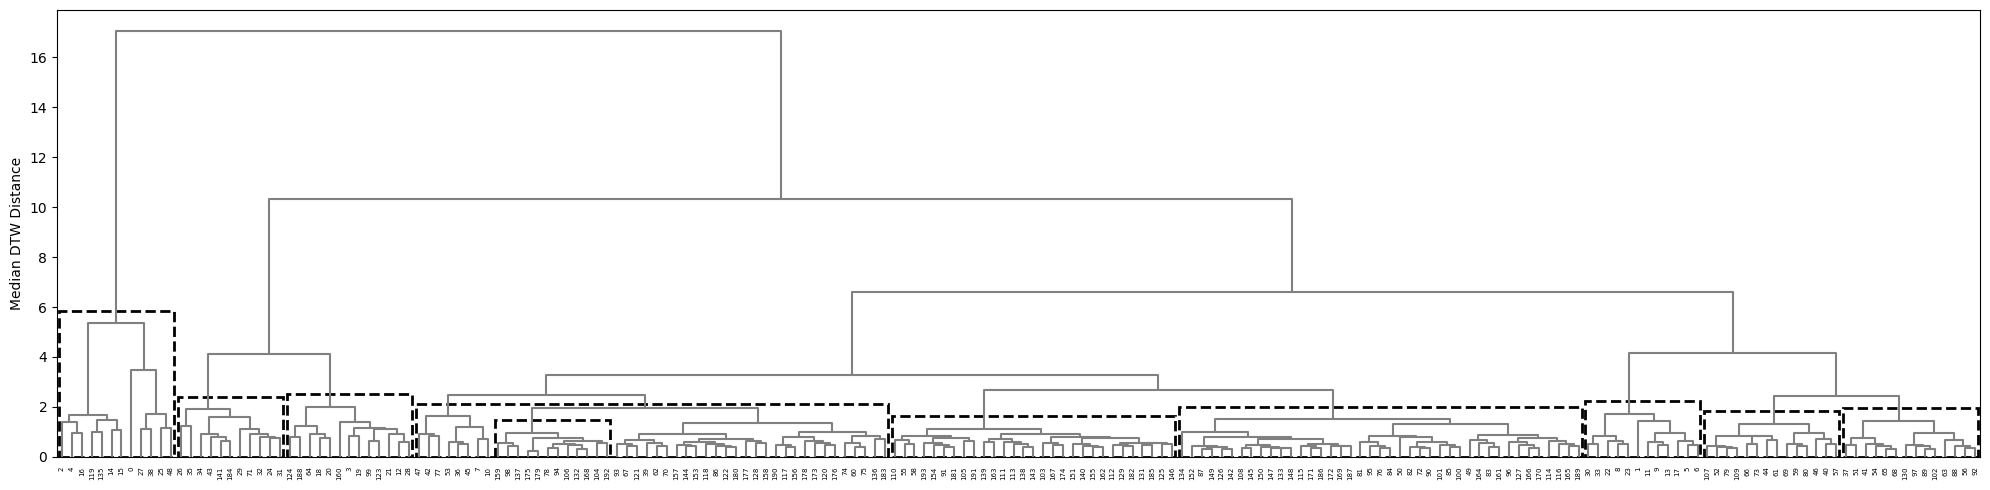

In [14]:
plt.figure(figsize=(20, 5))


# --- dendrogram ---
ddata = dendrogram(Z, link_color_func=lambda k: "grey")

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()

# x positions of leaves (scipy convention)
x_positions = np.arange(len(leaf_order)) * 10 + 5

# --- build tree structure to get correct heights ---
n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

# --- compute height per cluster ---
cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])

# --- draw one box per cluster ---
gap = 2  # spacing so boxes don't touch

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    x0 = x_positions[idx.min()] - 5 + gap
    x1 = x_positions[idx.max()] + 5 - gap
    height = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (x0, 0),
        x1 - x0,
        height,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

plt.ylabel("Median DTW Distance")
plt.tight_layout()
plt.savefig("../plots/nuug_dendrogram.pdf", dpi=300)
plt.show()

In [99]:
cl = 9

cluster = segments[clusters == cl].copy().reset_index(drop=True)
# cluster["label"] = labs[clusters == cl]
cluster

,start,stop,most_anomalous_start,scores,control_scores
0,2017-06-17T23:39:11.680001Z,2017-06-18T00:17:31.680001Z,2017-06-17T23:40:01.680001Z,0.737263,0.711354
1,2017-03-10T10:01:41.680001Z,2017-03-10T10:05:51.680001Z,2017-03-10T10:02:31.680001Z,0.729234,0.377912
2,2017-01-29T02:11:41.680001Z,2017-01-29T02:19:11.680001Z,2017-01-29T02:12:31.680001Z,0.716197,0.459733
3,2017-05-26T23:07:31.680001Z,2017-05-26T23:10:51.680001Z,2017-05-26T23:08:21.680001Z,0.691934,0.428958
4,2017-05-31T23:55:51.680001Z,2017-05-31T23:58:21.680001Z,2017-05-31T23:55:51.680001Z,0.690715,0.369397
5,2017-01-29T14:25:51.680001Z,2017-01-29T14:33:21.680001Z,2017-01-29T14:27:31.680001Z,0.686385,0.490783
6,2017-01-24T09:45:51.680001Z,2017-01-24T09:49:11.680001Z,2017-01-24T09:46:41.680001Z,0.669697,0.456603
7,2017-01-23T15:09:11.680001Z,2017-01-23T15:12:31.680001Z,2017-01-23T15:10:01.680001Z,0.660183,0.420810
8,2017-01-23T15:05:51.680001Z,2017-01-23T15:08:21.680001Z,2017-01-23T15:06:41.680001Z,0.649989,0.419752
9,2017-01-24T09:43:21.680001Z,2017-01-24T09:45:01.680001Z,2017-01-24T09:43:21.680001Z,0.641872,NaN


In [129]:
seg = cluster.iloc[11]
print(seg)
dt = str(seg["most_anomalous_start"])[:10]
t0 = obspy.UTCDateTime(seg["start"]) - timedelta(minutes=2)
t1 = obspy.UTCDateTime(seg["stop"]) + timedelta(minutes=2)

start                   2017-03-22T00:05:51.680001Z
stop                    2017-03-22T00:07:31.680001Z
most_anomalous_start    2017-03-22T00:05:51.680001Z
scores                                     0.608622
control_scores                                  NaN
Name: 11, dtype: object


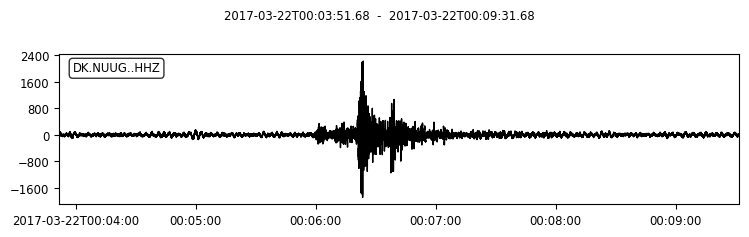

In [130]:
st = obspy.read(find_date_in_strings(nuug_paths, dt)[0])
preproc_stream(st)
st.trim(t0, t1)
st.plot()
plt.show()

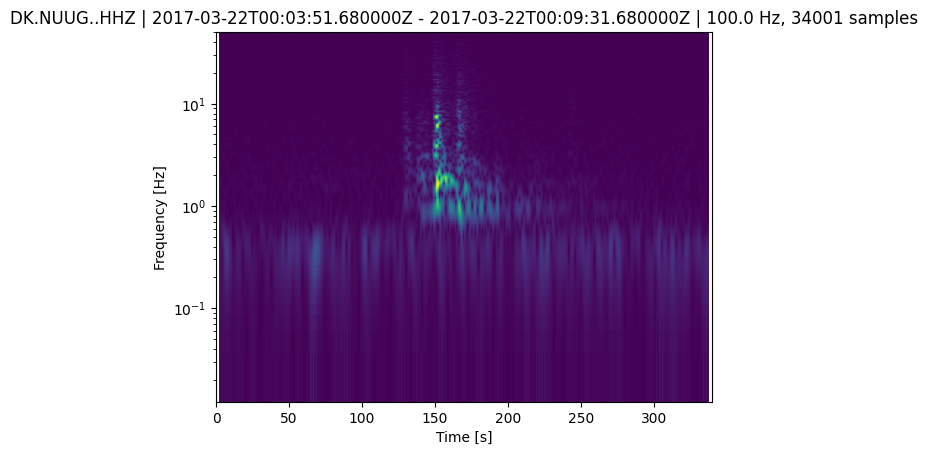

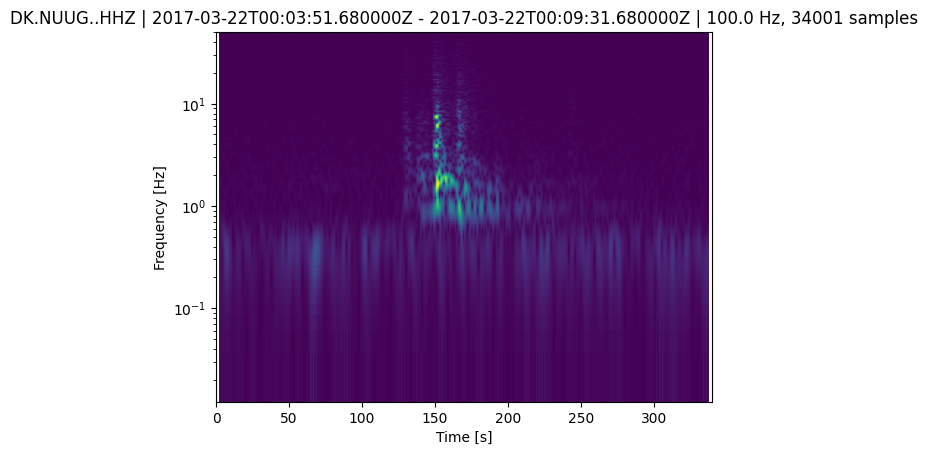

In [131]:
st[0].spectrogram(log=True, wlen=4, show=False)

In [16]:
segments["cluster"] = clusters

In [18]:
segments.to_csv(f"../output/{network}/if/segments/{station}.csv")